#**Complete processing pipeline for LOFAR as passive radar**

###Link to Google Drive
Change the `folder_path` to the Google Drive folder where the codes are saved.

The first time it is executed, the first line should be uncommented.

In [1]:
#!pip install skyfield lofarantpos
import os
import sys
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/Colab THESIS'
file_path = os.path.join(folder_path, 'spacetrack.py')

if not os.path.exists(folder_path):
    print("ERROR: Folder not found.")
elif not os.path.exists(file_path):
    print("ERROR: 'spacetrack.py' not found.")
else:
    print("File found.")

    if folder_path not in sys.path:
        sys.path.insert(0, folder_path)

    import importlib
    try:
        import spacetrack
        from spacetrack import get_iss, get_pointing_coords, bistatic_params
        importlib.reload(spacetrack)
        print("Import done")
    except Exception as e:
        print(f"ERROR to import: {e}")

Mounted at /content/drive
File found.
Import done


##Visualization of UDP packet

Valid data: packet 24515!
Timestamp: 1741133434, 2025-03-05 00:10:34
RSP Version: 3
RSP ID: 0 | Unused 1: 0 | RSP Error: 0 | Clock Bit: 1
Bit Mode: 0 | Unused 2: 0
Config: 170
Station ID: 6880
Number of beamlets: 61
Number of time samples: 16
Timestamp: 1741133434
Sequence: 1599


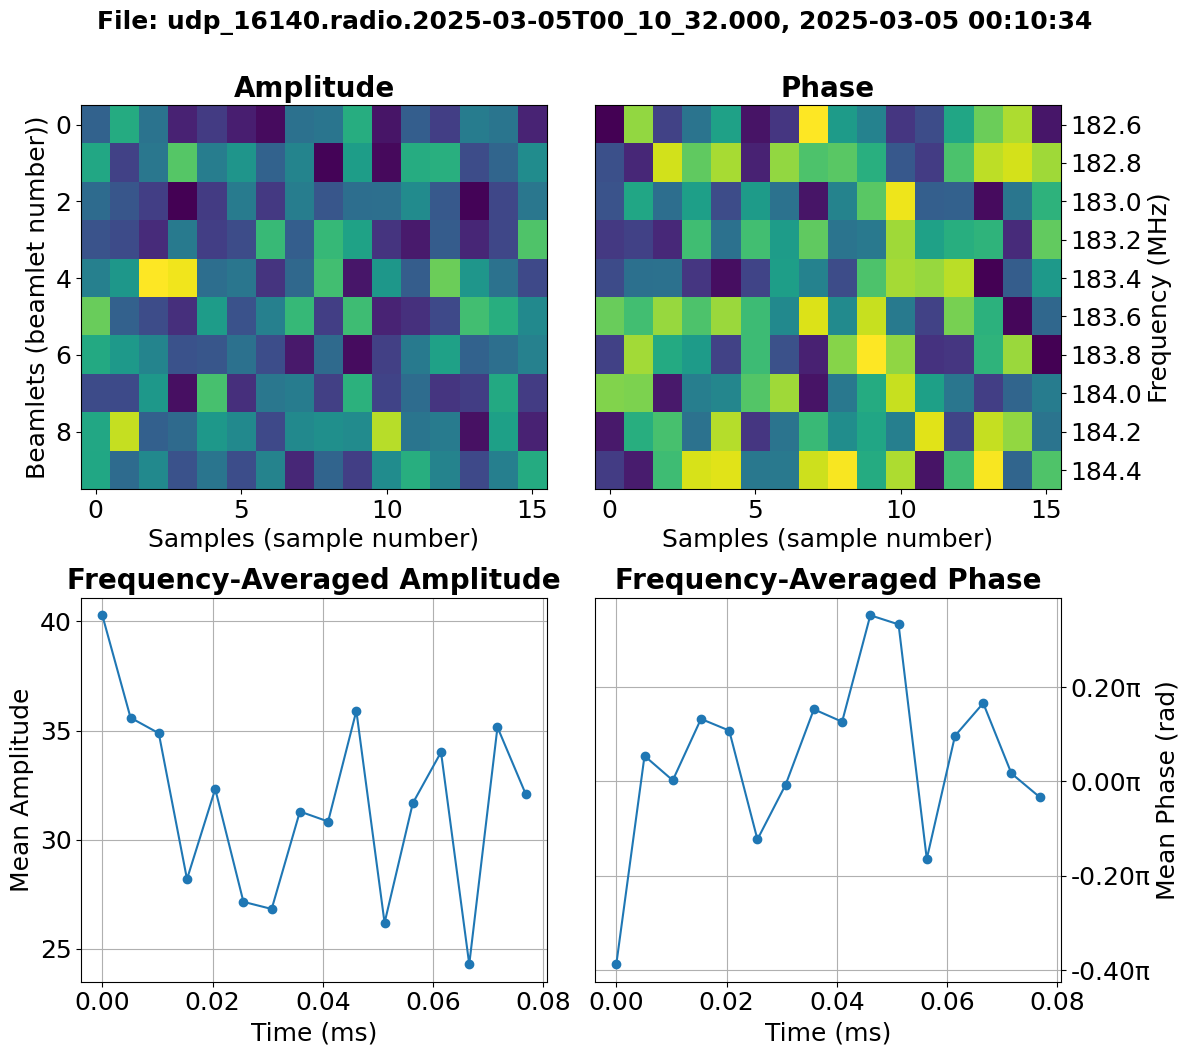

In [23]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timezone

filename = "/content/drive/MyDrive/Colab THESIS/observation_data/udp_16140.radio.2025-03-05T00_10_32.000"
valid_packet_data = None
pack_counter = 0
valid_count = 0
clk = 200e6
nyq_zone = 2 #nyquist zone II for clock frequency = 200MHz goes from 100-200 MHz

with open(filename, "rb") as f:
    while True:
        packet = f.read(7824)
        if len(packet) < 7824:
            break # End of file

        pack_counter += 1

        # 16-byte header
        header = packet[:16]
        rsp_version = header[0]

        byte1 = format(header[1], '08b')
        clock_bit = int(byte1[0], 2)       # Bit 7 (1 character to the left)
        rsp_error = int(byte1[1], 2)       # Bit 6
        unused_1 = int(byte1[2], 2)        # Bit 5
        rsp_id = int(byte1[-5:], 2)        # Bits 0-4 (5 characters to the right)

        byte2 = format(header[2], '08b')
        unused_2 = int(byte2[:6], 2)       # Bits 2-7 (6 character to the left)
        bit_mode = int(byte2[-2:], 2)      # Bits 0-1 (2 characters to the right)

        config = header[3]
        beamlets = header[6]
        time_samples = header[7]

        station_id = struct.unpack('<H', header[4:6])[0] # 2 bytes (H)
        timestamp = struct.unpack('<I', header[8:12])[0] # 4 bytes (I) 60-80ns from p to p
        sequence = struct.unpack('<I', header[12:16])[0] # 4 bytes (I)

        full_date = datetime.fromtimestamp(timestamp, timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

        data = packet[16:]

        # Read as 16-bit integers (combines every 2 bytes into 1 number)
        antenna_data = np.frombuffer(data, dtype=np.int16)

        # If there's any non-zero data, we process it and stop.
        if np.any(antenna_data):
            valid_count += 1
            if valid_count > 100: #changing this number i change the packet i see
                # Reshape: 61 beamlets x 16 samples x 4 parts (X_real, X_imag, Y_real, Y_imag)
                valid_packet_data = antenna_data.reshape((61, 16, 4))
                print(f"Valid data: packet {pack_counter}!")
                print(f"Timestamp: {timestamp}, {full_date}")
                break

if valid_packet_data is not None:
    print(f"RSP Version: {rsp_version}")
    print(f"RSP ID: {rsp_id} | Unused 1: {unused_1} | RSP Error: {rsp_error} | Clock Bit: {clock_bit}")
    print(f"Bit Mode: {bit_mode} | Unused 2: {unused_2}")
    print(f"Config: {config}")
    print(f"Station ID: {station_id}")
    print(f"Number of beamlets: {beamlets}")
    print(f"Number of time samples: {time_samples}")
    print(f"Timestamp: {timestamp}")
    print(f"Sequence: {sequence}")

    # Extract the Real and Imaginary parts for Antenna X (indices 0 and 1)
    # Convert to float to prevent overflow during mathematical operations
    real_part = valid_packet_data[:, :, 0].astype(float)
    imag_part = valid_packet_data[:, :, 1].astype(float)

    # Calculate Amplitude and Phase
    amplitude = np.sqrt(real_part**2 + imag_part**2)
    phase = np.arctan2(imag_part, real_part)

    # AUTOMATIC DETECTION OF ZERO PACKET
    beamlet_max = np.max(amplitude, axis=1)
    beamlet_w_data = np.where(beamlet_max > 0)[0]

    if len(beamlet_w_data) > 0:
        ylim = beamlet_w_data[-1]
    else:
        ylim = 61

    amplitude = amplitude[beamlet_w_data, :]
    phase = phase[beamlet_w_data, :]

    fig = plt.figure(figsize=(12, 10))

    ax1 = plt.subplot(2, 2, 1)  # Top left
    ax1.tick_params(axis='both', labelsize=18)
    ax1.imshow(amplitude, aspect='auto', interpolation='none', cmap='viridis')
    ax1.set_title("Amplitude",fontsize=20, fontweight='bold')
    ax1.set_xlabel("Samples (sample number)",fontsize=18)
    ax1.set_ylabel("Beamlets (beamlet number))",fontsize=18)

    ax2 = plt.subplot(2, 2, 2)  # Top right
    ax2.tick_params(axis='both', labelsize=18)
    recorded_sb = np.array([423,424,425,426,427,428,429,430,431,432])
    freqs = ((nyq_zone - 1 + (recorded_sb/512))*(clk/2))/1e6
    ax2.imshow(phase, aspect='auto', interpolation='none', cmap='viridis')
    ax2.set_title("Phase",fontsize=20, fontweight='bold')
    ax2.set_xlabel("Samples (sample number)",fontsize=18)
    ax2.set_yticks(np.arange(len(freqs)))
    ax2.set_yticklabels(np.round(freqs, 1))
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel("Frequency (MHz)",fontsize=18)

    dt_ms = (1024/clk) * 1000
    time_samples = np.arange(amplitude.shape[1]) * dt_ms

    ax3 = plt.subplot(2, 2, 3)
    ax3.tick_params(axis='both', labelsize=18)
    mean_amplitude = np.mean(amplitude, axis=0)
    ax3.plot(time_samples, mean_amplitude, marker='o')
    ax3.set_title("Frequency-Averaged Amplitude",fontsize=20, fontweight='bold')
    ax3.set_ylabel("Mean Amplitude",fontsize=18)
    ax3.set_xlabel("Time (ms)",fontsize=18)
    ax3.grid(True)

    ax4 = plt.subplot(2, 2, 4)
    mean_phase = np.mean(phase, axis=0)
    ax4.tick_params(axis='both', labelsize=18)
    ax4.plot(time_samples, mean_phase/np.pi, marker='o')
    formatter = ticker.FuncFormatter(lambda x, pos: f"{x:.2f}π")
    ax4.yaxis.set_major_formatter(formatter)
    ax4.set_title("Frequency-Averaged Phase",fontsize=20, fontweight='bold')
    ax4.yaxis.tick_right()
    ax4.yaxis.set_label_position("right")
    ax4.set_ylabel("Mean Phase (rad)",fontsize=18)
    ax4.set_xlabel("Time (ms)",fontsize=18)
    ax4.grid(True)

    plt.tight_layout()
    plt.suptitle(f"File: {os.path.basename(filename)}, {full_date}", fontsize=18, fontweight='bold', y=1.05)
    plt.show()

## Modeling the DAB+ reference signal

---


Create model by using DAB+ frame structure and duplicating MSC symbols in place of null, PR and FIC.

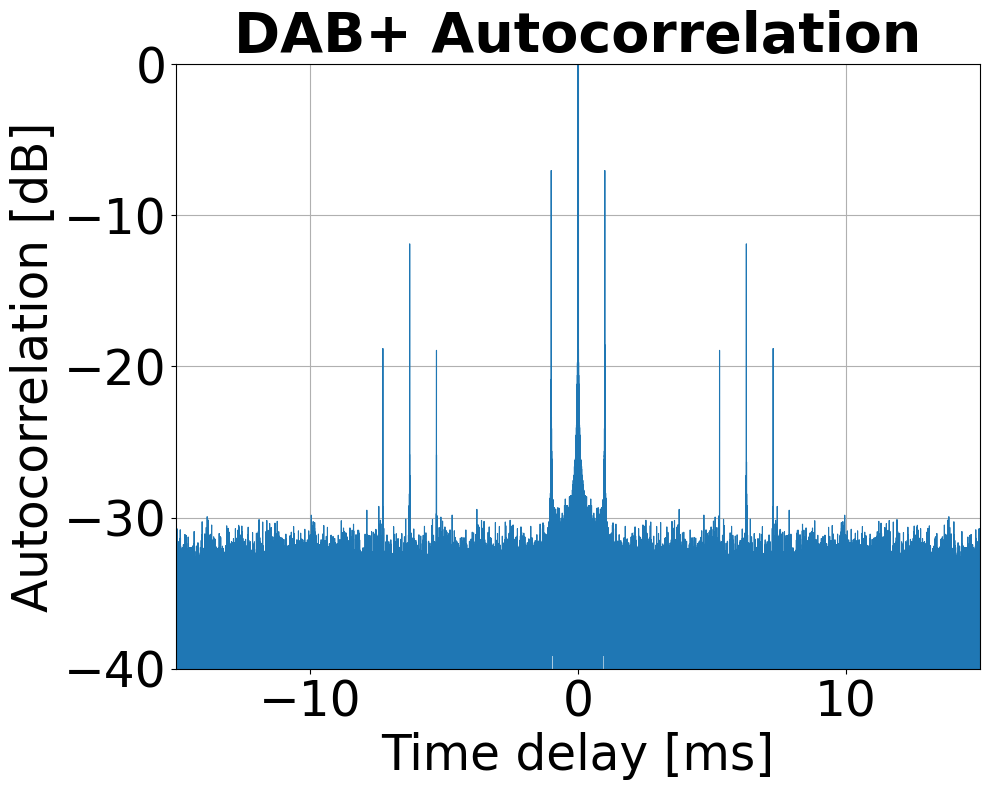

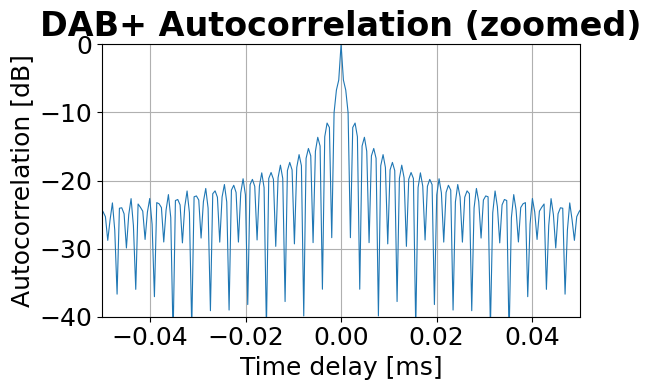

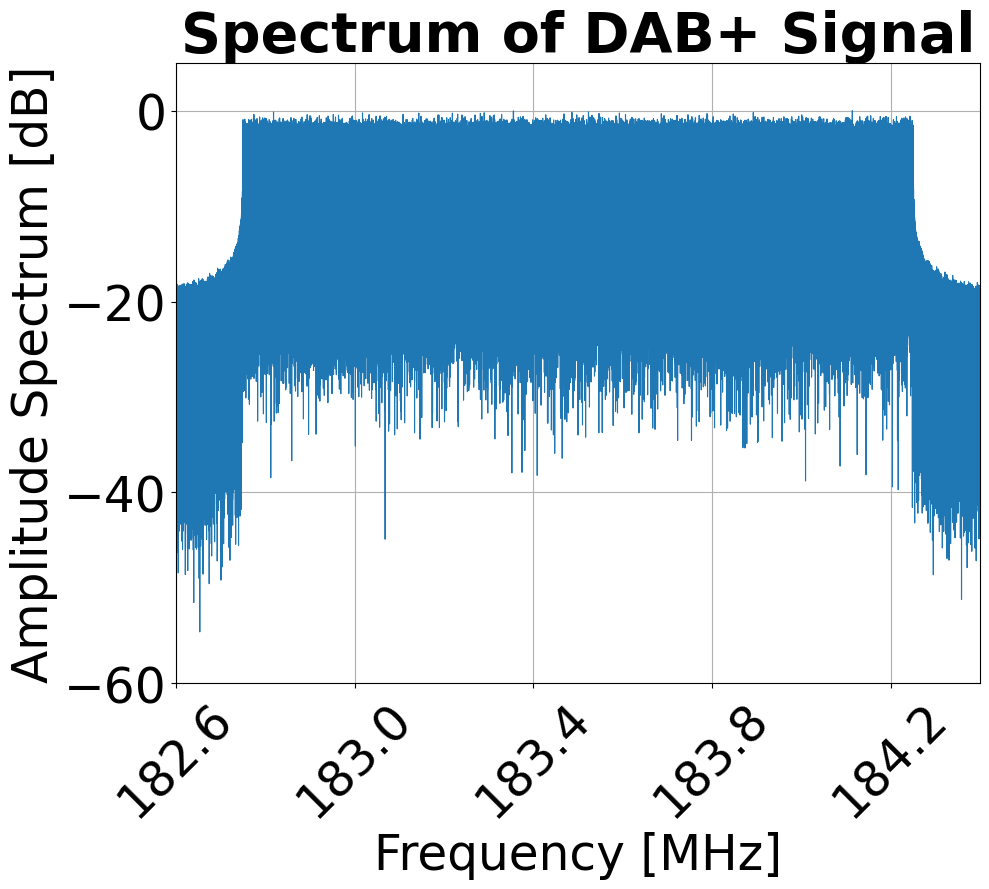

In [28]:
import numpy as np
import matplotlib.pyplot as plt

N_fft = 2048
N_subcarriers = 1536
fs = 2.048e6
num_frames = 65

CP_length = 504
null_length = 2656
symbol_length = N_fft + CP_length # 2552 samples per OFDM symbol

# size of block to replace
# Null (2656) + PR (1 * 2552) + FIC (3 * 2552) = 12864 samples
replace_length = null_length + 4 * symbol_length

time_signal = []

# idx of active subcarriers
half = N_subcarriers // 2
sc_indices = np.concatenate([np.arange(-half, 0), np.arange(1, half + 1)])
fft_bins = sc_indices % N_fft

prev_phase = 0
last_msc_block = np.zeros(replace_length, dtype=complex)

for frame in range(num_frames):
    #replace start of frame with msc
    time_signal.extend(last_msc_block)

    # generate 72 msc symbols
    current_msc = []
    for _ in range(72):
        # DQPSK (pi/4)
        increments = np.random.choice([np.pi/4, 3*np.pi/4, -np.pi/4, -3*np.pi/4], N_subcarriers)
        prev_phase = prev_phase + increments
        active_data = np.exp(1j * prev_phase)

        spectrum = np.zeros(N_fft, dtype=complex)
        spectrum[fft_bins] = active_data

        time_symbol = np.fft.ifft(spectrum)
        time_symbol_cp = np.concatenate((time_symbol[-CP_length:], time_symbol))

        current_msc.extend(time_symbol_cp)
        time_signal.extend(time_symbol_cp)

    # save last msc symbols for the next
    current_msc_array = np.array(current_msc)
    last_msc_block = current_msc_array[-replace_length:]

time_signal = np.array(time_signal) * 50
noise_level = 0.005
noise = np.random.normal(0, noise_level, len(time_signal)) + 1j * np.random.normal(0, noise_level, len(time_signal))
final_signal = time_signal + noise

# Autocorrelation
autocorr = np.fft.fftshift(np.fft.ifft(np.abs(np.fft.fft(final_signal))**2))
autocorr_db = 10 * np.log10((np.abs(autocorr) + 1e-12) / np.max(np.abs(autocorr)))

lags = np.arange(-len(final_signal)//2, len(final_signal)//2)
time_axis_ms = (lags / fs) * 1000


#plots
plt.figure(figsize=(10, 8))
plt.tick_params(axis='both', labelsize=35)
plt.plot(time_axis_ms, autocorr_db, lw=0.8)
plt.xlim(-15, 15)
plt.ylim(-40, 0)
plt.xlabel("Time delay [ms]", fontsize=35)
plt.ylabel("Autocorrelation [dB]", fontsize=35)
plt.title("DAB+ Autocorrelation", fontsize=40, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

#plots
plt.figure(figsize=(6, 4))
plt.tick_params(axis='both', labelsize=18)
plt.plot(time_axis_ms, autocorr_db, lw=0.8)
plt.xlim(-0.05, 0.05)
plt.ylim(-40, 0)
plt.xlabel("Time delay [ms]", fontsize=18)
plt.ylabel("Autocorrelation [dB]", fontsize=18)
plt.title("DAB+ Autocorrelation (zoomed)", fontsize=24, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

#Spectrum
spectrum_out = np.fft.fftshift(np.fft.fft(final_signal))
amplitude_db = 10 * np.log10(np.abs(spectrum_out) + 1e-12)
amplitude_db -= np.max(amplitude_db)

frequencies = np.linspace(182.5, 184.5, len(final_signal))

plt.figure(figsize=(10, 9))
plt.tick_params(axis='both', labelsize=35)
plt.plot(frequencies, amplitude_db, lw=0.8)
plt.xlim(182.6, 184.4)
plt.ylim(-60, 5)
plt.xlabel("Frequency [MHz]", fontsize=35)
plt.ylabel("Amplitude Spectrum [dB]", fontsize=35)
plt.title("Spectrum of DAB+ Signal", fontsize=40, fontweight='bold')
plt.xticks(np.arange(182.6, 184.5, 0.4), rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Reference signal according to answer to reviewer's question

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
import gc

recording_time_seconds = 360
num_frames = int(recording_time_seconds / 0.096)

N_fft = 2048
N_subcarriers = 1536
fs = 2.048e6
lofar_fs = 195312.5

CP_length = 504
null_length = 2656
symbol_length = N_fft + CP_length

replace_length = null_length + 4 * symbol_length

# idx of active subcarriers
half = N_subcarriers // 2
sc_indices = np.concatenate([np.arange(-half, 0), np.arange(1, half + 1)])
fft_bins = sc_indices % N_fft

prev_phase = 0
last_msc_block = np.zeros(replace_length, dtype=np.complex64)

# process by chunks to avoid filling ram
matched_signal_chunks = []
frames_per_chunk = 50
noise_level = 0.005

print(f"generating and resampling {num_frames} frames per block")

for chunk_start in range(0, num_frames, frames_per_chunk):
    chunk_end = min(chunk_start + frames_per_chunk, num_frames)
    chunk_frames = chunk_end - chunk_start

    samples_per_frame = replace_length + (72 * symbol_length)
    chunk_signal = np.empty(chunk_frames * samples_per_frame, dtype=np.complex64)
    current_idx = 0

    # generate 2.048mhz signal
    for _ in range(chunk_frames):
        chunk_signal[current_idx : current_idx + replace_length] = last_msc_block
        current_idx += replace_length

        current_msc = np.empty(72 * symbol_length, dtype=np.complex64)
        msc_idx = 0

        for _ in range(72):
            increments = np.random.choice([np.pi/4, 3*np.pi/4, -np.pi/4, -3*np.pi/4], N_subcarriers)
            prev_phase = prev_phase + increments
            active_data = np.exp(1j * prev_phase)

            spectrum = np.zeros(N_fft, dtype=np.complex64)
            spectrum[fft_bins] = active_data

            time_symbol = np.fft.ifft(spectrum)
            time_symbol_cp = np.concatenate((time_symbol[-CP_length:], time_symbol))

            sym_len = len(time_symbol_cp)
            current_msc[msc_idx : msc_idx + sym_len] = time_symbol_cp
            msc_idx += sym_len

            chunk_signal[current_idx : current_idx + sym_len] = time_symbol_cp
            current_idx += sym_len

        last_msc_block = current_msc[-replace_length:]

    # add noise
    chunk_signal *= 50
    chunk_signal += np.random.normal(0, noise_level, len(chunk_signal)).astype(np.float32) + \
                    1j * np.random.normal(0, noise_level, len(chunk_signal)).astype(np.float32)

    # resample
    resampled_chunk = resample_poly(chunk_signal, up=lofar_fs * 10, down=fs * 10)
    matched_signal_chunks.append(resampled_chunk.astype(np.complex64))

    # empty memory
    del chunk_signal, current_msc
    gc.collect()

    print(f"frames done: {chunk_end}/{num_frames}")

# join
print("joining blocks")
final_signal = np.concatenate(matched_signal_chunks)
del matched_signal_chunks
gc.collect()

print(f"size: {len(final_signal)} samples at {lofar_fs} Hz.")

generating and resampling 3750 frames per block
frames done: 50/3750
frames done: 100/3750
frames done: 150/3750
frames done: 200/3750
frames done: 250/3750
frames done: 300/3750
frames done: 350/3750
frames done: 400/3750
frames done: 450/3750
frames done: 500/3750
frames done: 550/3750
frames done: 600/3750
frames done: 650/3750
frames done: 700/3750
frames done: 750/3750
frames done: 800/3750
frames done: 850/3750
frames done: 900/3750
frames done: 950/3750
frames done: 1000/3750
frames done: 1050/3750
frames done: 1100/3750
frames done: 1150/3750
frames done: 1200/3750
frames done: 1250/3750
frames done: 1300/3750
frames done: 1350/3750
frames done: 1400/3750
frames done: 1450/3750
frames done: 1500/3750
frames done: 1550/3750
frames done: 1600/3750
frames done: 1650/3750
frames done: 1700/3750
frames done: 1750/3750
frames done: 1800/3750
frames done: 1850/3750
frames done: 1900/3750
frames done: 1950/3750
frames done: 2000/3750
frames done: 2050/3750
frames done: 2100/3750
frames

## Surveillance signal plot

BW: 182.6714375-184.6245625


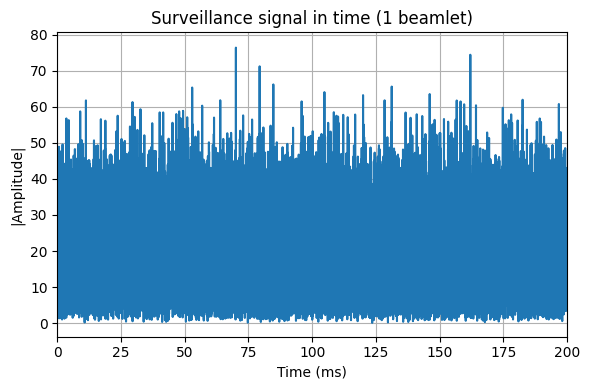

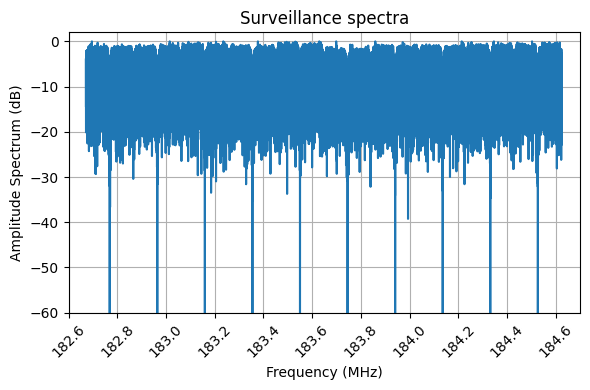

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

surv = np.memmap("/content/drive/MyDrive/Colab THESIS/signals/surveillance.dat",
                 dtype='complex64', mode='r', shape=(5000000, 61, 16))

spectra = []
time_samples = surv[:5000, 5, :].flatten()

for b in range(10):
    samples = surv[:5000, b, :].flatten() # take short fast fragment
    sp = 10 * np.log10(np.abs(fftshift(fft(samples))) + 1e-12)
    spectra.append(sp-np.max(sp))

spectra = np.concatenate(spectra)

fs = 200e6/1024
f_center = 183.648
bw = (10 * fs) / 1e6
f_start = f_center - (bw / 2)
f_end = f_center + (bw / 2)
print(f"BW: {f_start}-{f_end}")

frequencies = np.linspace(f_start, f_end, len(spectra))
time_ms = (np.arange(len(time_samples)) / fs) * 1000

plt.figure(figsize=(6, 4))
plt.plot(time_ms, np.abs(time_samples))
plt.xlim(0,200)
plt.title("Surveillance signal in time (1 beamlet)")
plt.xlabel("Time (ms)")
plt.ylabel("|Amplitude|")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.plot(frequencies, spectra)
plt.title("Surveillance spectra")
plt.xlabel("Frequency (MHz)")
plt.xlim(182.6, 184.7)
plt.xticks([182.6, 182.8, 183.0, 183.2, 183.4, 183.6,  183.8, 184.0, 184.2, 184.4, 184.6], rotation=45)
plt.ylabel("Amplitude Spectrum (dB)")
plt.ylim(-60,2)
plt.grid(True)
plt.tight_layout()
plt.show()

# **Full processing pipeline**

## Functions: Adaptive filter and Keystone transform

In [21]:
# BLOCK LATTICE FILTER: book signal processing for PBR chapter 5.3.2, table 5.4
# model DPI+clutter as weighted sum of m delayed copies of the reference signal
# maybe packs are not in order
# PLOT THE MODEL
def apply_block_lattice_filter(surv_signal, ref_signal, filter_order):
    N = len(surv_signal)
    M = filter_order

    ### Initialisation
    b = ref_signal.astype(np.complex64).copy()   # b_0(n) = x_r(n) backward prediction error
    f = ref_signal.astype(np.complex64).copy()   # f_0(n) = x_r(n) forward prediction error
    e = surv_signal.astype(np.complex64).copy()  # e_0(n) = x_e(n)

    ### M lattice stages
    for i in range(M):

        # b_i(n-1): shifting the b array one position to the right
        b_delayed = np.empty_like(b)
        b_delayed[0]  = 0          # zero-boundary (no wrap)
        b_delayed[1:] = b[:-1]

        ### Reflection coefficient k_{i+1}
        # numerator  : 2 · sum_n  b_i(n-1) · f_i*(n)
        # denominator: sum_n abs(f_i(n))^2 + abs(b_i(n-1))^2
        num   = 2.0 * np.dot(b_delayed, f.conj())
        denom = np.dot(f, f.conj()).real + np.dot(b_delayed, b_delayed.conj()).real
        kappa = num / (denom + 1e-30) # reflection coefficient for this stage: how much of b_delayed is present in f right now

        ### Prediction errors
        b_new = b_delayed - kappa * f
        f_new = f - kappa.conj() * b_delayed
        b = b_new
        f = f_new

        ### Filtering coef h_i
        # h scalar coefficient: how much of b is present in e
        h = np.dot(e, b.conj()) / (np.dot(b, b.conj()).real + 1e-30)

        ### clean echo
        e = e - h * b

    return e


# KEYSTONE TRANSFORM: correct range cell migration (to apply after FFT multiplication)
def keystone_transform(cross_spectrum, fs_fast, fs_slow):
    #cross_spectrum : complex array (num_batches, samples_per_batch)
    # Fast-frequency × slow-time cross-spectrum
    #fs_fast: fast time sampling rate (hz) after interpolation
    #fs_slow: slow time sampling rate (hz) = 1/dt_batch
    #out : complex array, same shape — range-migration-corrected cross-spectrum

    num_batches, fft_cols = cross_spectrum.shape
    t_slow = np.arange(num_batches) / fs_slow     # slow-time axis (s)
    t_slow_norm = t_slow / (t_slow[-1] + 1e-30)  # normalised  0 → 1
    out = np.zeros_like(cross_spectrum)

    for freq_bin in range(fft_cols):
        # Frequency of this bin (centred at DC after fftshift convention)
        f_bin  = (freq_bin - fft_cols // 2) * (fs_fast / fft_cols) #high frequency bins show faster migration
        # Scale factor
        scale  = 1.0 + f_bin / f_center
        t_scaled = np.clip(t_slow_norm * scale, 0.0, 1.0) #by resampling each column along the scaled slow-time axis, linear drift is removed

        col = cross_spectrum[:, freq_bin]
        col_abs = np.abs(col)
        col_phase = np.unwrap(np.angle(col))
        interp_abs = interp1d(t_slow_norm, col_abs, kind='linear', fill_value=0.0, bounds_error=False)
        interp_phase = interp1d(t_slow_norm, col_phase, kind='linear', fill_value=0.0, bounds_error=False)
        out[:, freq_bin] = interp_abs(t_scaled) * np.exp(1j * interp_phase(t_scaled))

        #After Keystone Transform, all 573 batches have the ISS echo aligned at the same range bin
    return out

##Getting to final CAF matrix:

####For each beamlet data: interpolation, adaptive filtering, batch algorithm (FFT and fast-time and slow-time processing), frequency and time domain windowing, range cell migration, peak detection.

Data downloaded, converting to Skyfield objects.
1 25544U 98067A   25063.86218454  .00012285  00000-0  22495-3 0  9997
2 25544  51.6348 103.7531 0006259 343.7461  16.3326 15.49724724498983
Bistatic range : 1647.06 km
Bistatic velocity: 9.3246 km/s
Processing: BEAMLET 0
Processing: BEAMLET 1
Processing: BEAMLET 2
Processing: BEAMLET 3
Processing: BEAMLET 4
Processing: BEAMLET 5
Processing: BEAMLET 6
Processing: BEAMLET 7
Processing: BEAMLET 8
Processing: BEAMLET 9


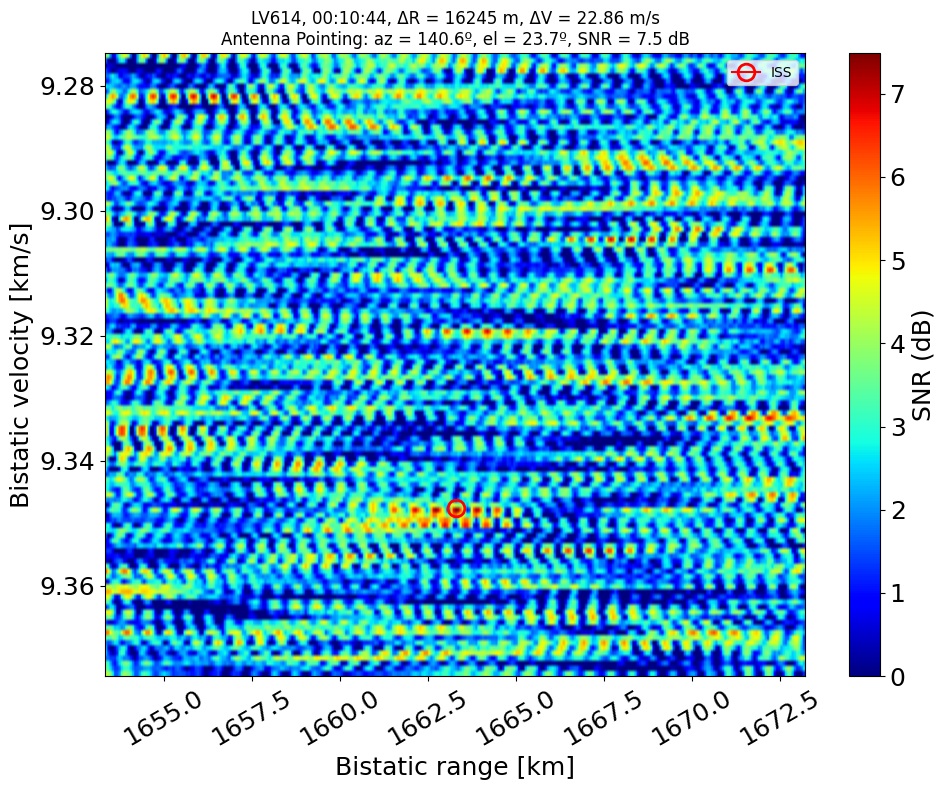

In [30]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft # for fast-time FFT for range correlation and slow-time FFT for Doppler
from scipy.signal import resample
from scipy.interpolate import interp1d
from astropy.constants import c
from datetime import datetime, timedelta
from skyfield.api import load, utc

folder_path = '/content/drive/MyDrive/Colab THESIS'
if folder_path not in sys.path:
    sys.path.append(folder_path)


c_val = c.value   # Speed of light (m/s)
f_center = 183.648e6   # DAB centre frequency (Hz)
lam = c_val / f_center  # Wavelength (m)
fs = 200e6 / 1024   # Sampling rate = 195.3125 kHz

# OBSERVATION DATE/TIME
full_date_dt = datetime.strptime(full_date, '%Y-%m-%d %H:%M:%S')
full_date_dt = full_date_dt + timedelta(seconds=10)
full_date = full_date_dt.strftime('%Y-%m-%d %H:%M:%S')
start_str = (full_date_dt - timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')
end_str = (full_date_dt + timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')


# ISS position and bistatic params
# load ISS TLE and propagate it to the exact observation instant
ts = load.timescale()
t = ts.from_datetime(full_date_dt.replace(tzinfo=utc))
iss_data, l1, l2 = get_iss(start_str, end_str, full_date_dt)
print(f"{l1}\n{l2}")
el, az = get_pointing_coords(iss_data, "LV614HBA", full_date_dt) #ISS elevation and azimuth angles as seen from the antenna

R_bistatic, V_bistatic = bistatic_params(iss_data, t)
print(f"Bistatic range : {R_bistatic/1000:.2f} km")
print(f"Bistatic velocity: {V_bistatic/1000:.4f} km/s")

### DIMENSIONS
int_time = 2 # CPI (Coherent Processing Interval) length (seconds)
num_samples = int(int_time * 195.3125e3)  # samples in raw CPI
interpolation_factor = 3  # sinc oversampling factor, if we used 3 · fs
max_delay_samples = 60 # max target delay (raw bins): defines the search region around the predicted range
filter_order = 30 * interpolation_factor    # lattice stages = 90

# for method 3 (batch algorithm): from 4.3.3, eq. 4.17 from book
samples_per_batch = 2048
total_interp_samples = num_samples * interpolation_factor
num_batches = total_interp_samples // samples_per_batch
crop_samples = num_batches * samples_per_batch
fft_size = num_batches  # Doppler FFT size = number of batches

# interpolation
range_pad_factor = 8
fft_size_padded = samples_per_batch * range_pad_factor
search_range_bins = max_delay_samples * interpolation_factor
search_range_bins_pad = search_range_bins * range_pad_factor  # padded search window

# Slow-time axis
dt_batch = samples_per_batch / (fs * interpolation_factor) # seconds per batch, slow-time sampling interval
fs_slow = 1.0 / dt_batch  # slow-time rate (Hz), slow-time sampling rate
doppler_res = fs_slow / fft_size   # Hz per Doppler bin
vel_res_kms = (doppler_res * lam) / 1000 # km/s per Doppler bin

#Initialise
total_caf = np.zeros((2 * search_range_bins_pad, fft_size), dtype=np.float32)

surveillance_disk = np.memmap("/content/drive/MyDrive/Colab THESIS/signals/surveillance.dat",
                              dtype='complex64', mode='r', shape=(5000000, 61, 16))


# BEAMLET PROCESSING LOOP
for b in range(10):
    print(f"Processing: BEAMLET {b}")

    num_packets = (num_samples // 16) + 1
    surv_raw = surveillance_disk[:num_packets, b, :].flatten()[:num_samples]
    ref_raw = final_signal[:num_samples]   #modeled DAB reference with Gaussian noise + CP

    # INTERPOLATION
    surv_interp = resample(surv_raw, total_interp_samples)
    ref_interp  = resample(ref_raw,  total_interp_samples)
    assert surv_interp.shape == ref_interp.shape, \
        f"Shape mismatch: surv={surv_interp.shape}, ref={ref_interp.shape}"


    # BLOCK LATTICE FILTER
    # unshifted ref to cancel DPI because the filter must cancel the zero-Doppler DPI and clutter, not the Doppler-shifted ISS echo
    # Block = 1 CPI
    surv_filtered_1d = apply_block_lattice_filter(surv_interp, ref_interp, filter_order=filter_order)

    # DOPPLER TUNING on ref
    f_iss_doppler = V_bistatic / lam
    time_interp = np.arange(total_interp_samples) / (fs * interpolation_factor)
    ref_tuned = ref_interp * np.exp(-1j * 2 * np.pi * f_iss_doppler * time_interp)
    # the opposite rotation to the ISS' is applied (with - in the exponent)
    # reference signal now has the same Doppler as the ISS echo --> when slow time FFT runs, the echo peak lands at Doppler 0

    # RANGE DELAY on ref --> x_r(t − R/c)
    # prealign reference delay to predicted iss range so that CAF peak appears near centre of search window
    center_delay_bin = int((R_bistatic / c_val) * fs * interpolation_factor)
    ref_tuned_coarse = np.zeros_like(ref_tuned)
    if center_delay_bin < len(ref_tuned):
        ref_tuned_coarse[center_delay_bin:] = \
            ref_tuned[:len(ref_tuned) - center_delay_bin]

    # RESHAPE to 2D batch matrices:
    # the signal is divided into Q (num_batches) blocks, each P (s_per_batch) samples long (eq. 4.17)
    matrix_surv = surv_filtered_1d[:crop_samples].reshape(num_batches, samples_per_batch)
    matrix_ref = ref_tuned_coarse[:crop_samples].reshape(num_batches, samples_per_batch)

    # FAST TIME FFT
    # the product is the cross spectrum: spectral domain version of CAF
    fft_surv = fft(matrix_surv, axis=1)
    fft_ref_conj = np.conj(fft(matrix_ref, axis=1))
    cross_spectrum = fft_surv * fft_ref_conj # (num_batches, samples_per_batch)

    # FREQUENCY-DOMAIN WINDOWING:
    # remove range sidelobes
    freq_window = np.fft.fftshift(np.hanning(samples_per_batch))
    #matrix_surv_w = matrix_surv * freq_window[np.newaxis, :] #window is broadcast over all Q batches simultaneously
    #matrix_ref_w = matrix_ref  * freq_window[np.newaxis, :]
    cross_spectrum_w = cross_spectrum * freq_window[np.newaxis, :]

    # KEYSTONE TRANSFORM
    # ISS ~8 km/s, in CPI = 2s, it moves ~16 km (> range resolution cell)
    cross_spectrum_kst = keystone_transform(cross_spectrum_w, fs * interpolation_factor, fs_slow)

    # IFFT
    range_matrix = ifft(cross_spectrum_kst, n=fft_size_padded, axis=1) # shape: (num_batches, fft_size_padded)
    range_matrix_shift = fftshift(range_matrix, axes=1)  # for having 0 delay in the middle
    center_bin = fft_size_padded // 2
    range_matrix_zoom  = range_matrix_shift[:, center_bin - search_range_bins_pad : center_bin + search_range_bins_pad]

     # TIME-DOMAIN WINDOWING
    # on slow-time axis to reduce Doppler sidelobes
    slow_window = np.hanning(num_batches)
    range_matrix_zoom_w  = range_matrix_zoom * slow_window[:, np.newaxis]

    # SLOW-TIME FFT (to get doppler dimension of CAF)
    doppler_matrix = fft(range_matrix_zoom_w, axis=0)  #each row of range_matrix_zoom_w is 1 range bin across slow time
    doppler_matrix_shifted = fftshift(doppler_matrix, axes=0)

    # Transpose so that rows = Range, cols = Doppler
    caf_beamlet = np.abs(doppler_matrix_shifted).T
    total_caf += caf_beamlet

caf_power = total_caf ** 2
#noise_floor = np.median(caf_power)

# Search where the peak is located
peak_r, peak_d = np.unravel_index(np.argmax(caf_power), caf_power.shape)

# Define size of rectangle to not take into account
guard_r = 20
guard_d = 5

#borders:
r0_n = max(0, peak_r - guard_r)
r1_n = min(caf_power.shape[0], peak_r + guard_r)
d0_n = max(0, peak_d - guard_d)
d1_n = min(caf_power.shape[1], peak_d + guard_d)

#fill with nan
caf_power_nan = caf_power.copy()
caf_power_nan[r0_n:r1_n, d0_n:d1_n] = np.nan

noise_floor = np.nanmedian(caf_power_nan)

final_caf_matrix = 10 * np.log10((caf_power + 1e-30) / (noise_floor + 1e-30))

# PLOTTING AXES SETUP
# Range axis
range_bin_m  = c_val / (fs * interpolation_factor * range_pad_factor)
range_bin_km = range_bin_m / 1000

full_range_axis_km = (np.arange(2 * search_range_bins_pad) - search_range_bins_pad) * range_bin_km + (R_bistatic / 1000)

# Doppler axis
velocity_zoom = 0.1  # km/s total display window
rows_in_zoom  = int((velocity_zoom / 2) / vel_res_kms)
rows_in_zoom  = min(rows_in_zoom, fft_size // 2 - 1)
center_d = fft_size // 2
d0 = center_d - rows_in_zoom
d1 = center_d + rows_in_zoom

######## PEAK DETECTION AND deltaR & deltaV EXTRACTION
caf_search_region = final_caf_matrix[:, :]
peak_r, peak_d = np.unravel_index(np.argmax(caf_search_region), caf_search_region.shape)

# Physical offsets from TLE-predicted position
delta_R = (peak_r - search_range_bins_pad) * range_bin_m   # m
delta_V = (peak_d - center_d) * doppler_res * lam  # m/s

peak_range_km = full_range_axis_km[peak_r]
peak_vel_kms  = V_bistatic / 1000 + delta_V / 1000

# Plot with zoom — +-10 km in range, +-velocity_zoom/2 in Doppler
display_range_km = 10
r_half = max(1, int(display_range_km / range_bin_km))
r0 = max(0, peak_r - r_half)
r1 = min(2 * search_range_bins_pad, peak_r + r_half)

zoomed_matrix = final_caf_matrix[r0:r1, d0:d1].T   # rows=Doppler, cols=Range

zoom_range_min = full_range_axis_km[r0]
zoom_range_max = full_range_axis_km[r1 - 1]
vel_half_km = rows_in_zoom * vel_res_kms
zoom_vel_min = V_bistatic / 1000 - vel_half_km
zoom_vel_max = V_bistatic / 1000 + vel_half_km

# PLOT
snr_peak = np.max(zoomed_matrix)

plt.figure(figsize=(10, 8))
plt.tick_params(axis='both', labelsize=18)
plt.imshow(zoomed_matrix, aspect='auto', cmap='jet', origin='upper',
           extent=[zoom_range_min, zoom_range_max, zoom_vel_max, zoom_vel_min])
plt.title(f"LV614, {full_date_dt.strftime('%H:%M:%S')}, ΔR = {delta_R:.0f} m, ΔV = {delta_V:.2f} m/s\nAntenna Pointing: az = {az:.1f}º, el = {el:.1f}º, SNR = {snr_peak:.1f} dB")
plt.xlabel("Bistatic range [km]", fontsize=18)
plt.ylabel("Bistatic velocity [km/s]",fontsize=18)
cbar = plt.colorbar()
cbar.set_label("SNR (dB)", size=18)
cbar.ax.tick_params(labelsize=18)
plt.clim(0, snr_peak)
plt.xticks(rotation=30)

plt.plot(peak_range_km, peak_vel_kms, marker='o', color='red', markersize=12, fillstyle='none', markeredgewidth=2, label="ISS")
plt.legend()

plt.tight_layout()
plt.savefig('caf.png')
plt.show()

## With plots in between

Data downloaded, converting to Skyfield objects.
1 25544U 98067A   25063.86218454  .00012285  00000-0  22495-3 0  9997
2 25544  51.6348 103.7531 0006259 343.7461  16.3326 15.49724724498983
Bistatic range : 1647.06 km
Bistatic velocity: 9.3246 km/s
Processing: BEAMLET 0
Processing: BEAMLET 1
Processing: BEAMLET 2
Processing: BEAMLET 3
Processing: BEAMLET 4
Processing: BEAMLET 5
Processing: BEAMLET 6
Processing: BEAMLET 7
Processing: BEAMLET 8
Processing: BEAMLET 9


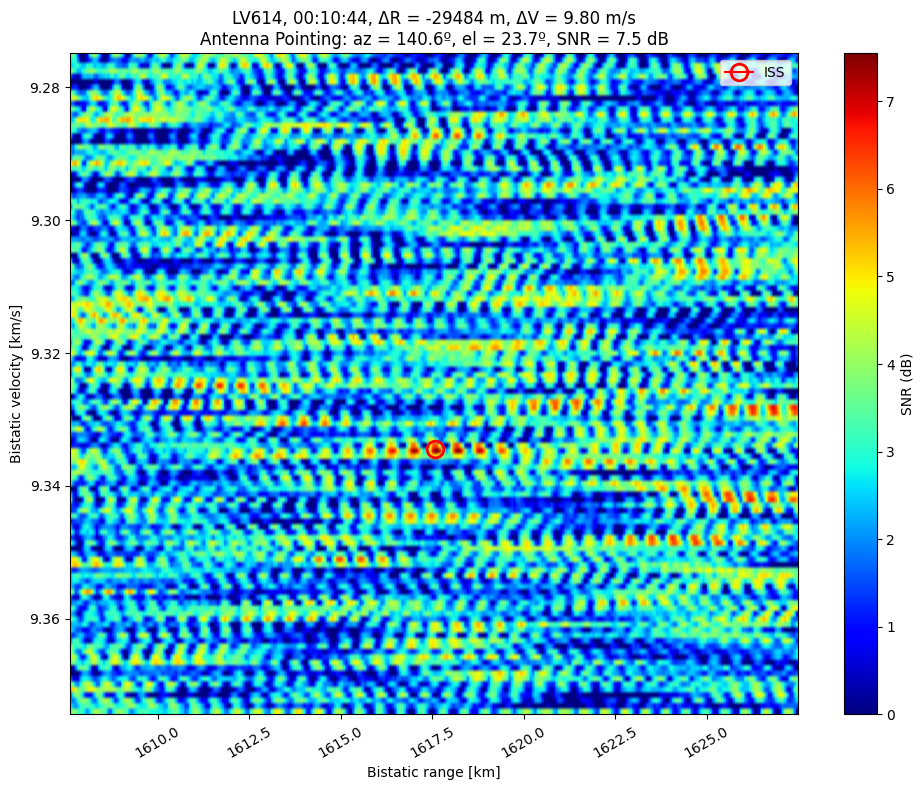

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft
from scipy.signal import resample
from scipy.interpolate import interp1d
from astropy.constants import c
from datetime import datetime, timedelta
from skyfield.api import load, utc

folder_path = '/content/drive/MyDrive/Colab THESIS'
if folder_path not in sys.path:
    sys.path.append(folder_path)

c_val = c.value
f_center = 183.648e6
lam = c_val / f_center
fs = 200e6 / 1024

# OBSERVATION DATE/TIME
full_date_dt = datetime.strptime(full_date, '%Y-%m-%d %H:%M:%S')
start_str = (full_date_dt - timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')
end_str = (full_date_dt + timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')

# ISS position and bistatic params
ts = load.timescale()
t = ts.from_datetime(full_date_dt.replace(tzinfo=utc))
iss_data, l1, l2 = get_iss(start_str, end_str, full_date_dt)
print(f"{l1}\n{l2}")
el, az = get_pointing_coords(iss_data, "LV614HBA", full_date_dt)

R_bistatic, V_bistatic = bistatic_params(iss_data, t)
print(f"Bistatic range : {R_bistatic/1000:.2f} km")
print(f"Bistatic velocity: {V_bistatic/1000:.4f} km/s")

### DIMENSIONS
int_time = 2
num_samples = int(int_time * 195.3125e3)
interpolation_factor = 3
max_delay_samples = 60
filter_order = 30 * interpolation_factor

samples_per_batch = 2048
total_interp_samples = num_samples * interpolation_factor
num_batches = total_interp_samples // samples_per_batch
crop_samples = num_batches * samples_per_batch
fft_size = num_batches

range_pad_factor = 8
fft_size_padded = samples_per_batch * range_pad_factor
search_range_bins = max_delay_samples * interpolation_factor
search_range_bins_pad = search_range_bins * range_pad_factor

dt_batch = samples_per_batch / (fs * interpolation_factor)
fs_slow = 1.0 / dt_batch
doppler_res = fs_slow / fft_size
vel_res_kms = (doppler_res * lam) / 1000

total_caf = np.zeros((2 * search_range_bins_pad, fft_size), dtype=np.float32)

surveillance_disk = np.memmap("/content/drive/MyDrive/Colab THESIS/signals/surveillance.dat",
                              dtype='complex64', mode='r', shape=(5000000, 61, 16))

range_bin_m  = c_val / (fs * interpolation_factor * range_pad_factor)
range_bin_km = range_bin_m / 1000
# BEAMLET PROCESSING LOOP
for b in range(10):
    print(f"Processing: BEAMLET {b}")

    num_packets = (num_samples // 16) + 1
    surv_raw = surveillance_disk[:num_packets, b, :].flatten()[:num_samples]
    ref_raw = final_signal[:num_samples]

    surv_interp = resample(surv_raw, total_interp_samples)
    ref_interp  = resample(ref_raw,  total_interp_samples)

    ### THESIS PLOT 1: Data ###
    if b == 0:
        surv_transf = fftshift(fft(surv_interp))
        ref_transf = fftshift(fft(ref_interp))
        freq_axis = np.linspace(f_center - (fs*interpolation_factor)/2,
                                f_center + (fs*interpolation_factor)/2,
                                len(surv_transf)) / 1e6

        plt.figure(figsize=(8,4))
        plt.plot(freq_axis, 20*np.log10(np.abs(surv_transf)+1e-12), label='Surveillance')
        plt.plot(freq_axis, 20*np.log10(np.abs(ref_transf)+1e-12), label='Reference')
        plt.title('Interpolated Signals')
        plt.ylabel("Amplitude (dB)")
        plt.xlabel("Frequency (MHz)")
        plt.xlim(182.6, 184.7)
        plt.legend()
        plt.grid()
        plt.savefig('thesis_step1_raw.png')
        plt.close()

    surv_filtered_1d = apply_block_lattice_filter(surv_interp, ref_interp, filter_order=filter_order)

    ### THESIS PLOT 2: Clutter Cancellation Effect ###
    if b == 0:
        n_show = 4096 #2 DAB symbols (2048*2)
        t_show_ms = (np.arange(n_show) / (fs*interpolation_factor)) *1e3
        plt.figure(figsize=(8,4))
        before_db = 20 * np.log10(np.abs(surv_interp[:n_show]) + 1e-30)
        after_db  = 20 * np.log10(np.abs(surv_filtered_1d[:n_show]) + 1e-30)

        sup_db = np.median(before_db) - np.median(after_db)

        plt.plot(t_show_ms, before_db, label='Before Lattice Filter', alpha=0.8)
        plt.plot(t_show_ms, after_db,  label='After Lattice Filter', alpha=0.8)
        plt.ylabel('Amplitude [dB]')
        plt.xlabel('Time [ms]')
        plt.title(f'DPI/Clutter Suppression, median suppresion = {sup_db:.1f} dB')
        plt.legend()
        plt.grid()
        plt.savefig('thesis_step2_filtering.png')
        plt.close()

    f_iss_doppler = V_bistatic / lam
    time_interp = np.arange(total_interp_samples) / (fs * interpolation_factor)
    ref_tuned = ref_interp * np.exp(-1j * 2 * np.pi * f_iss_doppler * time_interp)

    center_delay_bin = int((R_bistatic / c_val) * fs * interpolation_factor)
    ref_tuned_coarse = np.zeros_like(ref_tuned)
    if center_delay_bin < len(ref_tuned):
        ref_tuned_coarse[center_delay_bin:] = ref_tuned[:len(ref_tuned) - center_delay_bin]

    matrix_surv = surv_filtered_1d[:crop_samples].reshape(num_batches, samples_per_batch)
    matrix_ref = ref_tuned_coarse[:crop_samples].reshape(num_batches, samples_per_batch)

    freq_window = np.hanning(samples_per_batch)
    matrix_surv_w = matrix_surv * freq_window[np.newaxis, :]
    matrix_ref_w = matrix_ref  * freq_window[np.newaxis, :]

    ### PLOT A: Frequency-domain windowing effect on range sidelobes ###
    if b == 0:
        mid = num_batches // 2
        row_raw = matrix_surv[mid, :]
        row_windowed = matrix_surv_w[mid, :]

        spec_raw = fftshift(fft(row_raw))
        spec_win = fftshift(fft(row_windowed))

        db_raw = 20 * np.log10(np.abs(spec_raw) + 1e-30)
        db_win = 20 * np.log10(np.abs(spec_win) + 1e-30)
        db_raw -= np.max(db_raw)
        db_win -= np.max(db_win)

        bin_to_range_m = c_val / ((fs*interpolation_factor) * samples_per_batch)   # [m / bin]
        freq_bins = np.arange(samples_per_batch) - samples_per_batch // 2
        range_offset_m = bin_to_range_m * freq_bins

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(range_offset_m/1e3, db_raw, lw=0.8, alpha=0.8, label='No window (rect)')
        axes[0].plot(range_offset_m/1e3, db_win, lw=0.8, alpha=0.8, label='Hanning window')
        axes[0].set_xlabel('Range offset from batch centre [km]')
        axes[0].set_ylabel('Normalised power [dB]')
        axes[0].set_ylim(-80, 5)
        axes[0].set_title('Full fast-frequency spectrum: Rect vs Hanning')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        zoom_bins = 100

        axes[1].plot(range_offset_m[samples_per_batch//2 : samples_per_batch//2 + zoom_bins] / 1e3,
                     db_raw[samples_per_batch//2 : samples_per_batch//2 + zoom_bins], lw=0.8, alpha=0.8, label='No window (rect)')
        axes[1].plot(range_offset_m[samples_per_batch//2 : samples_per_batch//2 + zoom_bins] / 1e3,
                     db_win[samples_per_batch//2 : samples_per_batch//2 + zoom_bins], lw=0.8, alpha=0.85, label='Hanning')
        axes[1].set_xlim(5, 100)
        axes[1].set_ylim(-80, -5)
        axes[1].set_xlabel('Range offset from peak [km]')
        axes[1].set_ylabel('Normalised power [dB]')
        axes[1].set_title('Sidelobe zoom: first 100 bins')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(f'PLOT A: Range Sidelobe Reduction via Hanning Window \n(Beamlet {b}')
        plt.tight_layout()
        plt.savefig('thesis_plotA_range_windowing.png', dpi=120)
        plt.close()

    fft_surv = fft(matrix_surv_w, axis=1)
    fft_ref_conj = np.conj(fft(matrix_ref_w, axis=1))
    cross_spectrum = fft_surv * fft_ref_conj

    ### THESIS PLOT 3: Cross Spectrum Before Keystone ###
    slow_time_s = np.arange(num_batches) * (samples_per_batch/(fs*interpolation_factor))
    if b == 0:
        cs_db  = 20 * np.log10(np.abs(cross_spectrum) + 1e-30)
        vmax   = np.nanpercentile(cs_db, 99)

        # x-axis: fast-frequency bin (after IFFT becomes bistatic range)
        fast_bin_axis = np.arange(samples_per_batch)

        fig, ax = plt.subplots(figsize=(9, 5))
        im = ax.imshow(cs_db, aspect='auto', cmap='jet',
                       vmin=vmax - 50, vmax=vmax,
                       extent=[fast_bin_axis[0], fast_bin_axis[-1],
                                slow_time_s[-1], slow_time_s[0]])
        cb = fig.colorbar(im, ax=ax, label='Cross-spectrum power  [dB]')
        ax.set_xlabel(f'Fast-frequency bin  [0 … {samples_per_batch - 1}]  '
                      f'(→ bistatic range after IFFT,  {c_val / ((fs*interpolation_factor) * samples_per_batch):.1f} m / bin)')
        ax.set_ylabel(f'Slow time  [s]  (1 batch = {(samples_per_batch/(fs*interpolation_factor)) * 1e3:.2f} ms)')
        ax.set_title(f'Step 3: Cross-Spectrum  before  Keystone  '
                     f'(beamlet {b},  {num_batches} batches × {samples_per_batch} samples)')
        plt.tight_layout()
        plt.savefig('thesis_step3_cross_spectrum.png', dpi=120)
        plt.close()

    cross_spectrum_kst = keystone_transform(cross_spectrum, fs * interpolation_factor, fs_slow)

    ### THESIS PLOT 4: Cross Spectrum After Keystone ###
    if b == 0:
        plt.figure(figsize=(8,4))
        cs_k_db = 20 * np.log10(np.abs(cross_spectrum_kst) + 1e-30)
        vmax  = np.nanpercentile(cs_k_db,99)

        plt.imshow(cs_k_db, aspect='auto', cmap='jet', vmin=vmax-50, vmax=vmax,
                   extent=[fast_bin_axis[0],fast_bin_axis[-1],
                           slow_time_s[-1],slow_time_s[0]])
        plt.title('Step 4: Cross Spectrum (After Keystone Migration Correction)')
        plt.ylabel('Slow Time [s]')
        plt.xlabel('Fast Frequency bin')
        plt.colorbar(label='dB')
        plt.grid()
        plt.savefig('thesis_step4_keystone.png')
        plt.close()

    range_matrix = ifft(cross_spectrum_kst, n=fft_size_padded, axis=1)
    range_matrix_shift = fftshift(range_matrix, axes=1)
    center_bin = fft_size_padded // 2
    range_matrix_zoom  = range_matrix_shift[:, center_bin - search_range_bins_pad : center_bin + search_range_bins_pad]

    slow_window = np.hanning(num_batches)
    range_matrix_zoom_w  = range_matrix_zoom * slow_window[:, np.newaxis]

    ### PLOT B: Time-domain windowing effect on Doppler sidelobes ###
    if b == 0:
        iss_range_bin = search_range_bins_pad
        col_raw = range_matrix_zoom[:, iss_range_bin]
        col_windowed = range_matrix_zoom_w[:, iss_range_bin]

        doppler_raw = fftshift(fft(col_raw))
        doppler_win = fftshift(fft(col_windowed))

        db_d_raw = 20 * np.log10(np.abs(doppler_raw) + 1e-30)
        db_d_win = 20 * np.log10(np.abs(doppler_win) + 1e-30)
        db_d_raw -= np.max(db_d_raw)
        db_d_win -= np.max(db_d_win)

        doppler_bins = np.arange(num_batches) - num_batches // 2
        vel_axis_ms  = doppler_bins * doppler_res * lam

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(vel_axis_ms, db_d_raw, lw=0.8, alpha=0.8, label='No window (rect)')
        axes[0].plot(vel_axis_ms, db_d_win, lw=0.8, alpha=0.8, label='Hanning window')
        axes[0].set_xlabel('Bistatic velocity offset [m/s]')
        axes[0].set_ylabel('Normalised power [dB]')
        axes[0].set_ylim(-80, 5)
        axes[0].set_title('Full Doppler spectrum: Rect vs Hanning')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(vel_axis_ms, db_d_raw, lw=0.8, alpha=0.8, label='No window (rect)')
        axes[1].plot(vel_axis_ms, db_d_win, lw=0.8, alpha=0.8, label='Hanning window')
        axes[1].set_xlim(-50, 50)
        axes[1].set_ylim(-60, 5)
        axes[1].set_xlabel('Bistatic velocity offset [m/s]')
        axes[1].set_ylabel('Normalised power [dB]')
        axes[1].set_title('Sidelobe zoom: +-30 m/s around peak')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(f'PLOT B — Doppler Sidelobe Reduction via Hanning Window \n(Beamlet {b}, Range bin = predicted ISS)')
        plt.tight_layout()
        plt.savefig('thesis_plotB_doppler_windowing.png', dpi=120)
        plt.close()

    ### THESIS PLOT 5: Range Compression (1D slice) ###
    if b == 0:
        plt.figure(figsize=(8,4))
        mid_batch = num_batches // 2
        range_prof  = np.abs(range_matrix_zoom_w[mid_batch, :])
        range_prof_db = 20 * np.log10(range_prof + 1e-30)
        range_prof_db -= np.max(range_prof_db)

        range_axis_zoom_km = (np.arange(2 * search_range_bins_pad) - search_range_bins_pad) * range_bin_m / 1e3 + R_bistatic / 1e3

        plt.plot(range_axis_zoom_km, range_prof_db, lw=0.8)
        plt.title('Step 5: Range Compression Output (Single Batch)')
        plt.ylabel('Amplitude [dB]')
        plt.xlabel('Bistatic range [km]')
        plt.ylim(-50,3)
        plt.xlim(range_axis_zoom_km[0],range_axis_zoom_km[-1])
        plt.grid()
        plt.savefig('thesis_step5_range.png')
        plt.close()

    doppler_matrix = fft(range_matrix_zoom_w, axis=0)
    doppler_matrix_shifted = fftshift(doppler_matrix, axes=0)

    caf_beamlet = np.abs(doppler_matrix_shifted).T
    total_caf += caf_beamlet

# --- SNR AND FINAL CAF MATRIX ---
caf_power = total_caf ** 2
peak_r, peak_d = np.unravel_index(np.argmax(caf_power), caf_power.shape)

guard_r = 20
guard_d = 5
r0_n = max(0, peak_r - guard_r)
r1_n = min(caf_power.shape[0], peak_r + guard_r)
d0_n = max(0, peak_d - guard_d)
d1_n = min(caf_power.shape[1], peak_d + guard_d)

caf_power_nan = caf_power.copy()
caf_power_nan[r0_n:r1_n, d0_n:d1_n] = np.nan
noise_floor = np.nanmedian(caf_power_nan)

final_caf_matrix = 10 * np.log10((caf_power + 1e-30) / (noise_floor + 1e-30))

range_bin_m  = c_val / (fs * interpolation_factor * range_pad_factor)
range_bin_km = range_bin_m / 1000
full_range_axis_km = (np.arange(2 * search_range_bins_pad) - search_range_bins_pad) * range_bin_km + (R_bistatic / 1000)

velocity_zoom = 0.1
rows_in_zoom  = int((velocity_zoom / 2) / vel_res_kms)
rows_in_zoom  = min(rows_in_zoom, fft_size // 2 - 1)
center_d = fft_size // 2
d0 = center_d - rows_in_zoom
d1 = center_d + rows_in_zoom

caf_search_region = final_caf_matrix[:, :]
peak_r, peak_d = np.unravel_index(np.argmax(caf_search_region), caf_search_region.shape)

delta_R = (peak_r - search_range_bins_pad) * range_bin_m
delta_V = (peak_d - center_d) * doppler_res * lam

peak_range_km = full_range_axis_km[peak_r]
peak_vel_kms  = V_bistatic / 1000 + delta_V / 1000

display_range_km = 10
r_half = max(1, int(display_range_km / range_bin_km))
r0 = max(0, peak_r - r_half)
r1 = min(2 * search_range_bins_pad, peak_r + r_half)

zoomed_matrix = final_caf_matrix[r0:r1, d0:d1].T

zoom_range_min = full_range_axis_km[r0]
zoom_range_max = full_range_axis_km[r1 - 1]
vel_half_km = rows_in_zoom * vel_res_kms
zoom_vel_min = V_bistatic / 1000 - vel_half_km
zoom_vel_max = V_bistatic / 1000 + vel_half_km

snr_peak = np.max(zoomed_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(zoomed_matrix, aspect='auto', cmap='jet', origin='upper',
           extent=[zoom_range_min, zoom_range_max, zoom_vel_max, zoom_vel_min])
plt.title(f"LV614, {full_date_dt.strftime('%H:%M:%S')}, ΔR = {delta_R:.0f} m, ΔV = {delta_V:.2f} m/s\nAntenna Pointing: az = {az:.1f}º, el = {el:.1f}º, SNR = {snr_peak:.1f} dB")
plt.xlabel("Bistatic range [km]")
plt.ylabel("Bistatic velocity [km/s]")
plt.colorbar(label="SNR (dB)")
plt.clim(0, snr_peak)
plt.xticks(rotation=30)

plt.plot(peak_range_km, peak_vel_kms, marker='o', color='red', markersize=12, fillstyle='none', markeredgewidth=2, label="ISS")
plt.legend()

plt.tight_layout()
plt.savefig('caf.png')
plt.show()

##Temporal visualization

In [ ]:
file_start = datetime.strptime('2025-03-05 00:04:31', '%Y-%m-%d %H:%M:%S')
obs_start   = file_start # first timestamp

step_sec = 30       # seconds between observations
n_obs = 13

timestamps  = [obs_start + timedelta(seconds=i*step_sec) for i in range(n_obs)]

# storage
results = {
    'time': [],   # seconds since first observation
    'hours': [],
    'snr': [],   # dB
    'range_km': [],   # km
    'vel_kms': [],   # km/s
    'delta_R': [],   # m  (residual vs TLE)
    'delta_V': [],   # m/s
    }

total_pkts = surveillance_disk.shape[0]   # 5 000 000
file_duration = total_pkts * 16 / fs

for obs_idx, obs_dt in enumerate(timestamps):
    obs_str  = obs_dt.strftime('%Y-%m-%d %H:%M:%S')
    start_str = (obs_dt - timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')
    end_str = (obs_dt + timedelta(hours=12)).strftime('%Y-%m-%d %H:%M:%S')
    elapsed  = obs_idx * step_sec
    print(f"Observation {obs_idx+1}/{n_obs}  |  {obs_str}  |  t = {elapsed} s")

    ### ISS position for this timestamp
    t_sky = ts.from_datetime(obs_dt.replace(tzinfo=utc))
    iss_data, l1, l2 = get_iss(start_str, end_str, obs_dt)
    el, az = get_pointing_coords(iss_data, "LV614HBA", obs_dt)
    R_bistatic, V_bistatic = bistatic_params(iss_data, t_sky)

    print(f"R = {R_bistatic/1000:.2f} km, V = {V_bistatic/1000:.2f} km/s")

    ### sample offset into surveillance file: how many samples from the start of the file to this observation
    sample_offset = int(elapsed * fs)

    ### initialise CAF accumulator for this observation
    total_caf = np.zeros((2 * search_range_bins_pad, fft_size), dtype=np.float32)

    ## Doppler tuning
    f_iss_doppler = V_bistatic / lam
    time_interp = np.arange(total_interp_samples) / (fs * interpolation_factor)
    doppler_phasor = np.exp(-1j * 2 * np.pi * f_iss_doppler * time_interp)

    ## Range delay
    center_delay_bin = int((R_bistatic / c_val) * fs * interpolation_factor)

    for b in range(10):
        print(f"Beamlet {b}", end='\r')

        # read this observation's slice from the memory-mapped file
        pkt_start = sample_offset // 16

        num_packets = (num_samples // 16) + 1
        surv_raw = surveillance_disk[pkt_start : pkt_start + num_packets, b, :].flatten()[:num_samples]
        ref_raw = final_signal[sample_offset : sample_offset + num_samples]

        # interpolation
        surv_interp = resample(surv_raw, total_interp_samples)
        ref_interp  = resample(ref_raw,  total_interp_samples)

        # block lattice filter
        surv_filtered_1d = apply_block_lattice_filter(surv_interp, ref_interp, filter_order=filter_order)

        # doppler tuning
        ref_tuned = ref_interp * doppler_phasor

        # range delay
        ref_tuned_coarse = np.zeros_like(ref_tuned)
        if center_delay_bin < len(ref_tuned):
            ref_tuned_coarse[center_delay_bin:] = ref_tuned[:len(ref_tuned) - center_delay_bin]

        # reshape
        matrix_surv = surv_filtered_1d[:crop_samples].reshape(num_batches, samples_per_batch)
        matrix_ref = ref_tuned_coarse[:crop_samples].reshape(num_batches, samples_per_batch)

        # frequency-domain window
        freq_window = np.blackman(samples_per_batch)
        matrix_surv_w = matrix_surv * freq_window[np.newaxis, :]
        matrix_ref_w = matrix_ref  * freq_window[np.newaxis, :]

        # fast-time FFT + cross-spectrum
        fft_surv = fft(matrix_surv_w, axis=1)
        fft_ref_conj = np.conj(fft(matrix_ref_w, axis=1))
        cross_spectrum = fft_surv * fft_ref_conj

        # keystone transform
        cross_spectrum_kst = keystone_transform(cross_spectrum, fs * interpolation_factor, fs_slow)

        # IFFT
        range_matrix  = ifft(cross_spectrum_kst, n=fft_size_padded, axis=1)
        range_matrix_shift = fftshift(range_matrix, axes=1)
        center_bin = fft_size_padded // 2
        range_matrix_zoom = range_matrix_shift[:, center_bin - search_range_bins_pad : center_bin + search_range_bins_pad]

        # slow-time window + Doppler FFT
        slow_window = np.hanning(num_batches)
        range_matrix_zoom_w  = range_matrix_zoom * slow_window[:, np.newaxis]
        doppler_matrix       = fft(range_matrix_zoom_w, axis=0)
        doppler_matrix_shift = fftshift(doppler_matrix, axes=0)

        caf_beamlet = np.abs(doppler_matrix_shift).T
        total_caf += caf_beamlet

    ### Noise floor
    caf_power = total_caf ** 2
    peak_r, peak_d = np.unravel_index(np.argmax(caf_power), caf_power.shape)

    guard_r, guard_d = 20, 5
    noise_mask = np.ones_like(caf_power, dtype=bool)
    noise_mask[
        max(0, peak_r - guard_r) : min(caf_power.shape[0], peak_r + guard_r),
        max(0, peak_d - guard_d) : min(caf_power.shape[1], peak_d + guard_d)
    ] = False
    noise_floor = np.mean(caf_power[noise_mask])

    final_caf_matrix = 10 * np.log10((caf_power + 1e-30) / (noise_floor + 1e-30))

    ### measurements
    range_bin_m  = c_val / (fs * interpolation_factor * range_pad_factor)
    range_bin_km = range_bin_m / 1000
    center_d = fft_size // 2

    full_range_axis_km = (np.arange(2 * search_range_bins_pad) - search_range_bins_pad) * range_bin_km + (R_bistatic / 1000)

    delta_R = (peak_r - search_range_bins_pad) * range_bin_m
    delta_V = (peak_d - center_d) * doppler_res * lam
    peak_range = full_range_axis_km[peak_r]
    peak_vel = V_bistatic / 1000 + delta_V / 1000
    snr_peak = final_caf_matrix[peak_r, peak_d]

    print(f"SNR = {snr_peak:.1f} dB, R = {peak_range:.2f} km, V = {peak_vel:.4f} km/s, ΔR = {delta_R:.0f} m, ΔV = {delta_V:.2f} m/s")

    results['time'].append(elapsed)
    results['hours'].append(obs_dt.strftime('%H:%M:%S'))
    results['snr'].append(snr_peak)
    results['range_km'].append(peak_range)
    results['vel_kms'].append(peak_vel)
    results['delta_R'].append(delta_R)
    results['delta_V'].append(delta_V)

# CONVERT TO ARRAY
t_arr = np.array(results['time'])
hrs = np.array(results['hours'])
snr = np.array(results['snr'])
rng = np.array(results['range_km'])
vel = np.array(results['vel_kms'])

import matplotlib.dates as mdates

# PLOT
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f"ISS track: {obs_start.strftime('%H:%M:%S')} + 6 min", fontsize=20)

# SNR
ax = axes[0]
ax.plot(t_arr, snr, 'o-', color='red', markersize=6, label='SNR')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_ylabel('SNR (dB)')
ax.set_ylim(bottom=0)
ax.legend(loc='upper right')
ax.grid(True)
for xi, yi in zip(t_arr, snr):
    ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)

# Bistatic range
ax = axes[1]
ax.plot(t_arr, rng, 'o-', color='blue', markersize=6, label='Bistatic range')
ax.set_ylabel('Bistatic range (km)')
ax.legend(loc='upper right')
ax.grid(True)
for xi, yi in zip(t_arr, rng):
    ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)

# Bistatic velocity
ax = axes[2]
ax.plot(t_arr, vel, 'o-', color='green', markersize=6, label='Bistatic velocity')
ax.set_ylabel('Bistatic velocity (km/s)')
ax.set_xlabel('Time since start (s)')
ax.legend(loc='upper right')
ax.grid(True)
for xi, yi in zip(t_arr, vel):
    ax.annotate(f'{yi:.4f}', (xi, yi), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)

plt.xticks(t_arr, hrs, rotation=30)
#
plt.tight_layout()
plt.savefig('iss_track_6min.png', dpi=150, bbox_inches='tight')
plt.show()

Observation 1/13  |  2025-03-05 00:04:31  |  t = 0 s
Data downloaded, converting to Skyfield objects.
R = 4441.77 km, V = -13.51 km/s
SNR = 7.4 dB, R = 4387.41 km, V = -13.5100 km/s, ΔR = -54362 m, ΔV = -2.45 m/s
Observation 2/13  |  2025-03-05 00:05:01  |  t = 30 s
Data downloaded, converting to Skyfield objects.
R = 4037.75 km, V = -13.42 km/s
SNR = 6.9 dB, R = 4104.33 km, V = -13.3896 km/s, ΔR = 66578 m, ΔV = 31.03 m/s
Observation 3/13  |  2025-03-05 00:05:31  |  t = 60 s
Data downloaded, converting to Skyfield objects.
R = 3636.98 km, V = -13.29 km/s
SNR = 7.2 dB, R = 3657.70 km, V = -13.2524 km/s, ΔR = 20722 m, ΔV = 35.93 m/s
Observation 4/13  |  2025-03-05 00:06:01  |  t = 90 s
Data downloaded, converting to Skyfield objects.
R = 3241.10 km, V = -13.09 km/s
SNR = 8.2 dB, R = 3254.73 km, V = -13.1040 km/s, ΔR = 13623 m, ΔV = -13.88 m/s
Observation 5/13  |  2025-03-05 00:06:31  |  t = 120 s
Data downloaded, converting to Skyfield objects.
R = 2852.57 km, V = -12.79 km/s
SNR = 6.9 d